# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [2]:
# Using jupyter notebook locally. So, Skipping this cell
# # from google.colab import files
# # uploaded = files.upload()

In [3]:
# Load datasets
demographics = pd.read_csv("patient_demographics.csv")
clinical = pd.read_csv("clinical_data.csv")
lifestyle = pd.read_csv("lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [4]:
display(demographics.head())
demographics.info()
demographics.describe()

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Patient ID  8763 non-null   str  
 1   Age         8763 non-null   int64
 2   Sex         8763 non-null   str  
 3   Income      8763 non-null   int64
 4   Country     8763 non-null   str  
 5   Continent   8763 non-null   str  
 6   Hemisphere  8763 non-null   str  
dtypes: int64(2), str(5)
memory usage: 479.4 KB


,Age,Income
count,8763.000000,8763.000000
mean,53.707977,158263.181901
std,21.249509,80575.190806
min,18.000000,20062.000000
25%,35.000000,88310.000000
50%,54.000000,157866.000000
75%,72.000000,227749.000000
max,90.000000,299954.000000


In [5]:
display(clinical.head())
clinical.info()
clinical.describe()

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   str    
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   str    
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211


In [6]:
display(lifestyle.head())
lifestyle.info()
lifestyle.describe()

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   str    
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   str    
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Stress Level,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,0.896839,0.501426,0.598083,10.014284,5.469702,0.358211
std,0.304186,0.500026,0.490313,5.783745,2.859622,0.479502
min,0.000000,0.000000,0.000000,0.002442,1.000000,0.000000
25%,1.000000,0.000000,0.000000,4.981579,3.000000,0.000000
50%,1.000000,1.000000,1.000000,10.069559,5.000000,0.000000
75%,1.000000,1.000000,1.000000,15.050018,8.000000,1.000000
max,1.000000,1.000000,1.000000,19.998709,10.000000,1.000000


In [7]:
clinical.describe(include='all')

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763,8763.000000,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
unique,8763,NaN,3915,NaN,NaN,NaN,NaN,NaN
top,BMW7812,NaN,146/94,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,NaN,259.877211,NaN,75.021682,0.652288,0.492982,417.677051,28.891446
std,NaN,80.863276,NaN,20.550948,0.476271,0.499979,223.748137,6.319181
min,NaN,120.000000,NaN,40.000000,0.000000,0.000000,30.000000,18.002337
25%,NaN,192.000000,NaN,57.000000,0.000000,0.000000,225.500000,23.422985
50%,NaN,259.000000,NaN,75.000000,1.000000,0.000000,417.000000,28.768999
75%,NaN,330.000000,NaN,93.000000,1.000000,1.000000,612.000000,34.324594


In [8]:
display(demographics.isnull().sum())
display(clinical.isnull().sum())
lifestyle.isnull().sum()

Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64

Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
dtype: int64

Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [9]:
print(clinical['Blood Pressure'].dtype)

bp = clinical['Blood Pressure']
bp.head()

str


0     158/88
1     165/93
2     174/99
3    163/100
4      91/88
Name: Blood Pressure, dtype: str

In [10]:
pressureSplits = bp.str.split('/', expand = True)  # Series Object is first converted to str and 
# then splitted into the systolic and diastolic pressure.
# expand = True is there to convert the resultant series object into a dataframe
pressureSplits.rename(columns = {0:"Systolic BP", 1:"Diastolic BP"}, inplace=True) 
# Inplace = True makes the changes to the dataframe

# Pressure values can be made uint8, provided by numpy and not natural in python, 
# as the values will not exceed 255 and will always be positive.
pressureSplits = pressureSplits.astype({"Systolic BP" :np.uint8, "Diastolic BP":np.uint8}) 
pressureSplits.info()
pressureSplits.head()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Systolic BP   8763 non-null   uint8
 1   Diastolic BP  8763 non-null   uint8
dtypes: uint8(2)
memory usage: 17.2 KB


,Systolic BP,Diastolic BP
0,158,88
1,165,93
2,174,99
3,163,100
4,91,88


In [11]:
clinical.drop(columns = ["Blood Pressure"], inplace=True) # Remove the original column to remove redundancy
clinical = pd.concat([clinical, pressureSplits], axis=1)  # join the two dataframes
clinical.head()

,Patient ID,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic BP,Diastolic BP
0,BMW7812,208,72,0,0,286,31.251233,158,88
1,CZE1114,389,98,1,1,235,27.194973,165,93
2,BNI9906,324,72,1,0,587,28.176571,174,99
3,JLN3497,383,73,1,1,378,36.464704,163,100
4,GFO8847,318,93,1,1,231,21.809144,91,88


In [12]:
# This can also be done a lot easier with 
clinical = pd.read_csv("clinical_data.csv")

clinical[['Systolic', 'Diastolic']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(np.uint8)
display(clinical.describe())
clinical.info()

,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446,135.075659,85.156111
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181,26.349976,14.676565
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337,90.000000,60.000000
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985,112.000000,72.000000
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999,135.000000,85.000000
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594,158.000000,98.000000
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211,180.000000,110.000000


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   str    
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   str    
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
 8   Systolic        8763 non-null   uint8  
 9   Diastolic       8763 non-null   uint8  
dtypes: float64(1), int64(5), str(2), uint8(2)
memory usage: 564.9 KB


In [13]:
clinical['Systolic'].mean()

np.float64(135.07565902088325)

## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [14]:
display(demographics.isna().sum())
display(clinical.isna().sum())
display(lifestyle.isna().sum())

Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64

Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
Systolic          0
Diastolic         0
dtype: int64

Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

In [15]:
demographics.dropna(axis=1, how='any')

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere
...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,235420,Thailand,Asia,Northern Hemisphere
8759,QSV6764,28,Female,217881,Canada,North America,Northern Hemisphere
8760,XKA5925,47,Male,36998,Brazil,South America,Southern Hemisphere
8761,EPE6801,36,Male,209943,Brazil,South America,Southern Hemisphere


In [16]:
clinical.dropna(axis=1, how='any')

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88
...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,121,94/76,61,1,1,67,19.655895,94,76
8759,QSV6764,120,157/102,73,1,0,617,23.993866,157,102
8760,XKA5925,250,161/75,105,0,1,527,35.406146,161,75
8761,EPE6801,178,119/67,60,1,0,114,27.294020,119,67


In [17]:
lifestyle.dropna(axis=1, how='any')

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0
...,...,...,...,...,...,...,...,...
8758,MSV9918,1,0,1,7.917342,Healthy,8,0
8759,QSV6764,0,1,0,16.558426,Healthy,8,0
8760,XKA5925,1,1,1,3.148438,Average,5,1
8761,EPE6801,1,0,0,3.789950,Unhealthy,5,0


# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


In [18]:
# # Your code here
# import math
# # First identify the numerical columns of the dataset
demographics_numeric = demographics.select_dtypes(include=["uint8", "int64", "float64"]).columns.tolist()
clinical_numeric = clinical.select_dtypes(include=["uint8", "int64", "float64"]).columns.tolist()
lifestyle_numeric = lifestyle.select_dtypes(include=["uint8", "int64", "float64"]).columns.tolist()
print(demographics_numeric, clinical_numeric, lifestyle_numeric)

# # Plot the histogram with density curve and also with a mean line
# n = len(demographics_numeric)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(demographics_numeric):
#         ax.set_visible(False)
#         continue
#     sns.histplot(data = demographics, x = demographics_numeric[i], kde=True, ax=ax)
#     ax.axvline(demographics[demographics_numeric[i]].mean(), linestyle="--", color="red", label="Mean")
#     ax.set_title(f"{demographics_numeric[i]} Distribution", fontweight="bold")
#     ax.legend()


# n = len(clinical_numeric)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(clinical_numeric):
#         ax.set_visible(False)
#         continue
#     sns.histplot(data = clinical, x = clinical_numeric[i], kde=True, ax=ax)
#     ax.axvline(clinical[clinical_numeric[i]].mean(), linestyle="--", color="red", label="Mean")
#     ax.set_title(f"{clinical_numeric[i]} Distribution",fontweight="bold")
#     ax.legend()


# n = len(lifestyle_numeric)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(lifestyle_numeric):
#         ax.set_visible(False)
#         continue
#     sns.histplot(data = lifestyle, x = lifestyle_numeric[i], kde=True, ax=ax)
#     ax.axvline(lifestyle[lifestyle_numeric[i]].mean(), linestyle="--", color="red", label="Mean")
#     ax.set_title(f"{lifestyle_numeric[i]} Distribution",fontweight="bold")
#     ax.legend()

['Age', 'Income'] ['Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Triglycerides', 'BMI', 'Systolic', 'Diastolic'] ['Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Stress Level', 'Heart Attack Risk']


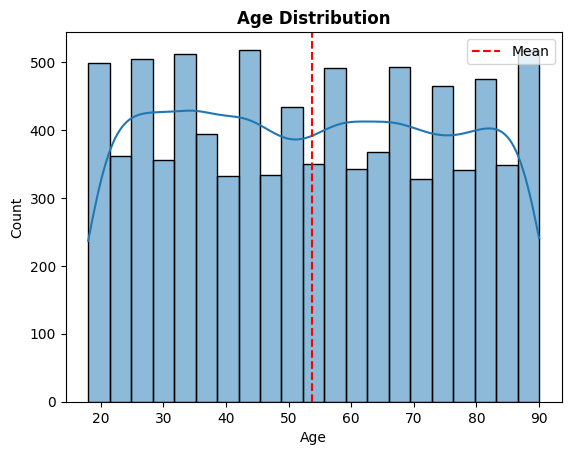

In [19]:
sns.histplot(data = demographics, x = "Age", kde=True)
plt.axvline(demographics["Age"].mean(), linestyle="--", color="red", label="Mean")
plt.title("Age Distribution",fontweight="bold")
plt.legend()

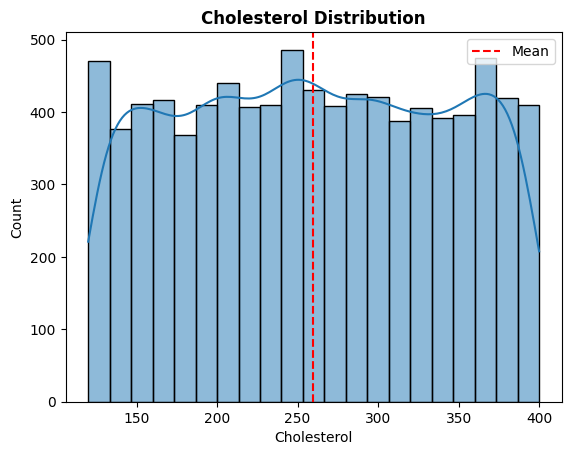

In [20]:
sns.histplot(data = clinical, x = "Cholesterol", kde=True)
plt.axvline(clinical["Cholesterol"].mean(), linestyle="--", color="red", label="Mean")
plt.title("Cholesterol Distribution",fontweight="bold")
plt.legend()

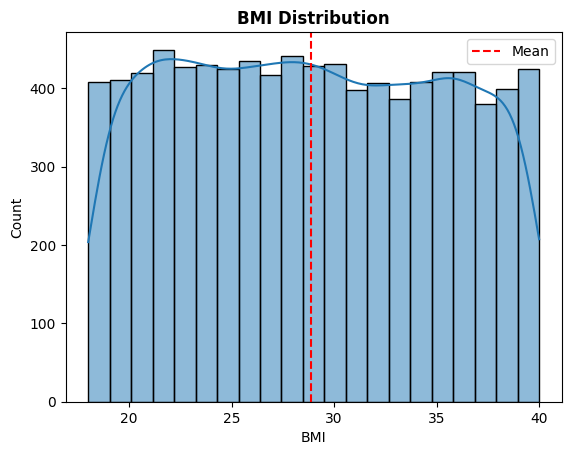

In [21]:
sns.histplot(data = clinical, x = "BMI", kde=True)
plt.axvline(clinical["BMI"].mean(), linestyle="--", color="red", label="Mean")
plt.title("BMI Distribution",fontweight="bold")
plt.legend()

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

In [22]:
# # Your code here
# import math
# # First identify the categorical columns of the dataset
# demographics_cat = demographics.select_dtypes(include=["str"]).columns.tolist()
# clinical_cat = clinical.select_dtypes(include=["str"]).columns.tolist()
# lifestyle_cat= lifestyle.select_dtypes(include=["str"]).columns.tolist()
# demographics_cat.remove('Patient ID')
# clinical_cat.remove('Patient ID')
# lifestyle_cat.remove('Patient ID')
# print(demographics_cat, clinical_cat, lifestyle_cat)


# # Your code here
# # Plot the count plots of all the categorical columns

# n = len(demographics_cat)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(demographics_cat):
#         ax.set_visible(False)
#         continue
#     sns.countplot(data = demographics, x = demographics_cat[i], order=demographics[demographics_cat[i]].value_counts().head(10).index, ax=ax)
#     ax.set_title(f"{demographics_cat[i]} Count Plot",fontweight="bold")
#     ax.tick_params(axis='x',rotation = 45)
#     ax.legend()

# n = len(demographics_cat)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(demographics_cat):
#         ax.set_visible(False)
#         continue
#     sns.countplot(data = demographics, x = demographics_cat[i], order=demographics[demographics_cat[i]].value_counts().head(10).index, ax=ax)
#     ax.set_title(f"{demographics_cat[i]} Count Plot",fontweight="bold")
#     ax.tick_params(axis='x',rotation = 45)

# n = len(clinical_cat)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(clinical_cat):
#         ax.set_visible(False)
#         continue
#     sns.countplot(data = clinical, x = clinical_cat[i], order=clinical[clinical_cat[i]].value_counts().head(10).index, ax=ax)
#     ax.set_title(f"{clinical_cat[i]} Count Plot",fontweight="bold")
#     ax.tick_params(axis='x',rotation = 45)

# n = len(lifestyle_cat)
# cols = 2
# rows = math.ceil(n / cols)
# fig,axes = plt.subplots(nrows= rows, ncols=cols, figsize= (5 * cols, 5 * rows))
# axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
# for i, ax in enumerate(axes):
#     if i >= len(lifestyle_cat):
#         ax.set_visible(False)
#         continue
#     sns.countplot(data = lifestyle, x = lifestyle_cat[i], order=lifestyle[lifestyle_cat[i]].value_counts().head(10).index, ax=ax)
#     ax.set_title(f"{lifestyle_cat[i]} Count Plot",fontweight="bold")
#     ax.tick_params(axis='x',rotation = 45)

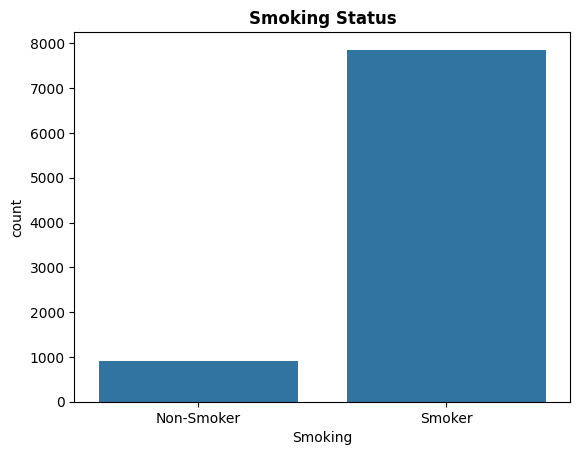

In [23]:
# Your code here
sns.countplot(data = lifestyle, x = 'Smoking', order=[0,1])
plt.xticks(ticks=[0, 1], labels=["Non-Smoker", "Smoker"])
plt.title("Smoking Status",fontweight="bold");

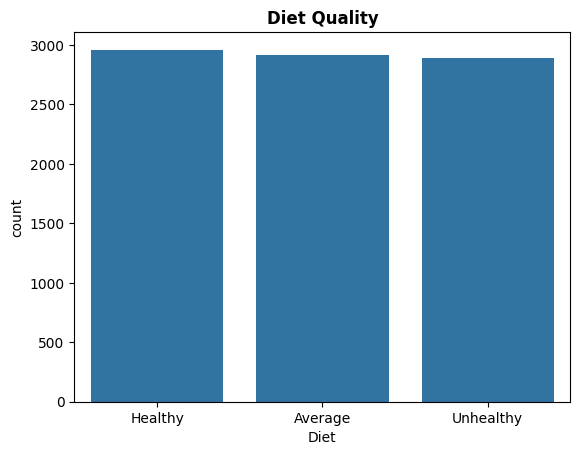

In [24]:
# Your code here
sns.countplot(data = lifestyle, x = 'Diet', order=lifestyle['Diet'].value_counts().index)
plt.title("Diet Quality",fontweight="bold");

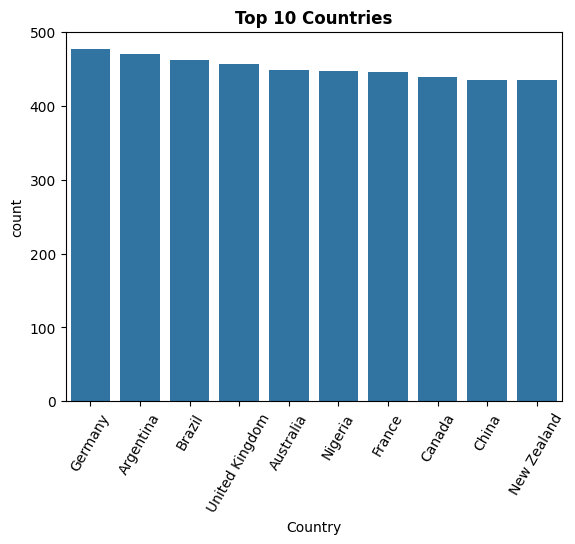

In [25]:
# Your code here
sns.countplot(data = demographics, x = 'Country', order=demographics['Country'].value_counts().head(10).index)
plt.title("Top 10 Countries",fontweight="bold")
plt.xticks(rotation=60);

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

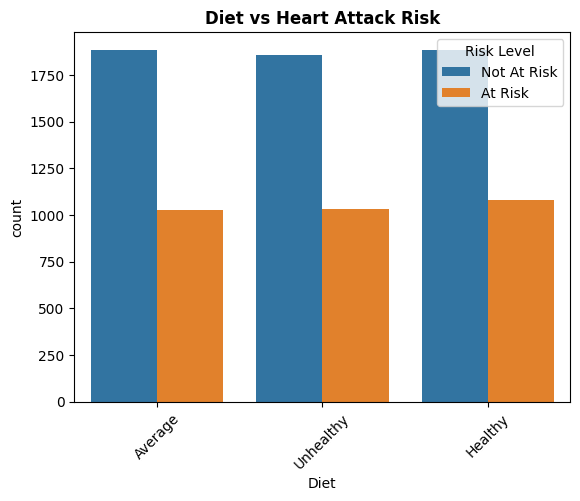

In [26]:
# Your code here
sns.countplot(data = lifestyle, x = 'Diet', hue = "Heart Attack Risk")
plt.title(f"Diet vs Heart Attack Risk",fontweight="bold")
plt.xticks(rotation=45)
handles, labels = plt.gca().get_legend_handles_labels()

new_labels = ['Not At Risk' if label in ['0',0] else "At Risk" for label in labels]

plt.legend(handles, new_labels, title="Risk Level");

([<matplotlib.axis.XTick at 0x73e9d911b170>,
 [Text(0, 0, 'Non-Smoker'), Text(1, 0, 'Smoker')])

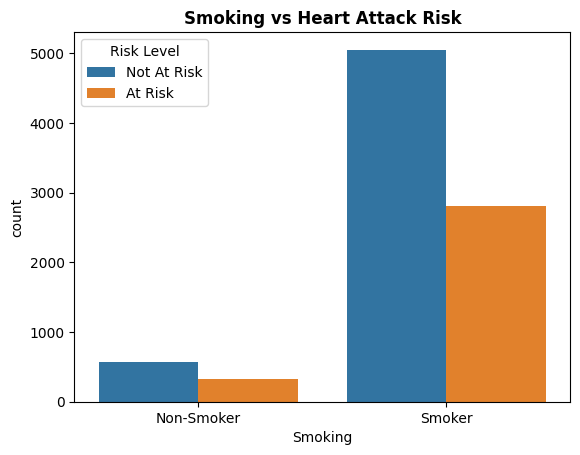

In [27]:
# Your code here
sns.countplot(data = lifestyle, x = 'Smoking', hue = "Heart Attack Risk")
plt.title(f"Smoking vs Heart Attack Risk",fontweight="bold")
handles, labels = plt.gca().get_legend_handles_labels()

new_labels = ['Not At Risk' if label in ['0',0] else "At Risk" for label in labels]

plt.legend(handles, new_labels, title="Risk Level");
plt.xticks(ticks=[0, 1], labels=["Non-Smoker", "Smoker"])

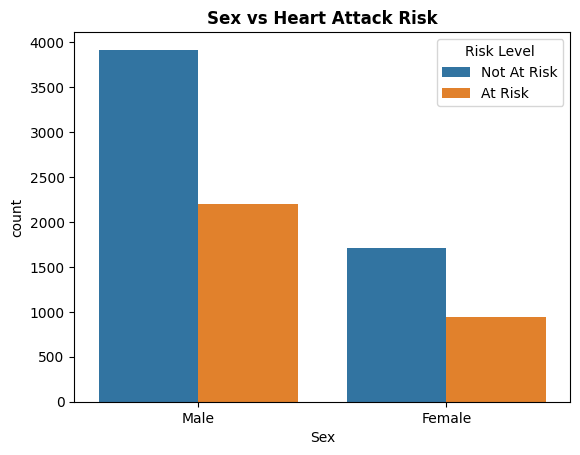

In [28]:
# Your code here
demo_life_merged = demographics.merge(lifestyle[['Patient ID', 'Heart Attack Risk']], on="Patient ID", how="inner")

sns.countplot(data = demo_life_merged, x = 'Sex', hue = "Heart Attack Risk")
plt.title(f"Sex vs Heart Attack Risk",fontweight="bold")
handles, labels = plt.gca().get_legend_handles_labels()

new_labels = ['Not At Risk' if label in ['0',0] else "At Risk" for label in labels]

plt.legend(handles, new_labels, title="Risk Level");

In [29]:
# Your code here
# sns.countplot(data = lifestyle, x = 'Alcohol Consumption', hue = "Heart Attack Risk")
# plt.title(f"Alchohol Consumption vs Heart Attack Risk",fontweight="bold")
# handles, labels = plt.gca().get_legend_handles_labels()

# new_labels = ['Not At Risk' if label in ['0',0] else "At Risk" for label in labels]

# plt.legend(handles, new_labels, title="Risk Level");
# plt.xticks(ticks=[0, 1], labels=["Non-Consumer", "Consumer"])


# sns.countplot(data = lifestyle, x = 'Obesity', hue = "Heart Attack Risk")
# plt.title(f"Obesity vs Heart Attack Risk",fontweight="bold")
# handles, labels = plt.gca().get_legend_handles_labels()

# new_labels = ['Not At Risk' if label in ['0',0] else "At Risk" for label in labels]

# plt.legend(handles, new_labels, title="Risk Level");
# plt.xticks(ticks=[0, 1], labels=["Non-Obese", "Obese"])


# sns.countplot(data = lifestyle, x = 'Stress Level', hue = "Heart Attack Risk")
# plt.title(f"Stress Level vs Heart Attack Risk",fontweight="bold")
# handles, labels = plt.gca().get_legend_handles_labels()

# new_labels = ['Not At Risk' if label in ['0',0] else "At Risk" for label in labels]

# plt.legend(handles, new_labels, title="Risk Level");


# df = pd.DataFrame(lifestyle.groupby('Smoking')['Heart Attack Risk'].mean())
# df.plot(kind='bar', figsize=(6,4))
# plt.ylabel("Average Heart Attack Risk")
# plt.title("Smoking vs Avg Heart Attack Risk")

# df = pd.DataFrame(lifestyle.groupby('Diet')['Heart Attack Risk'].mean())
# df.plot(kind='bar', figsize=(6,4))
# plt.ylabel("Average Heart Attack Risk")
# plt.title("Diet vs Avg Heart Attack Risk")

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [30]:
merged_df = lifestyle[lifestyle_numeric+["Patient ID"]].merge(clinical[clinical_numeric+["Patient ID"]], on ="Patient ID", how='inner')
merged_df = merged_df.merge(demographics[demographics_numeric+["Patient ID"]], on ="Patient ID", how='inner')

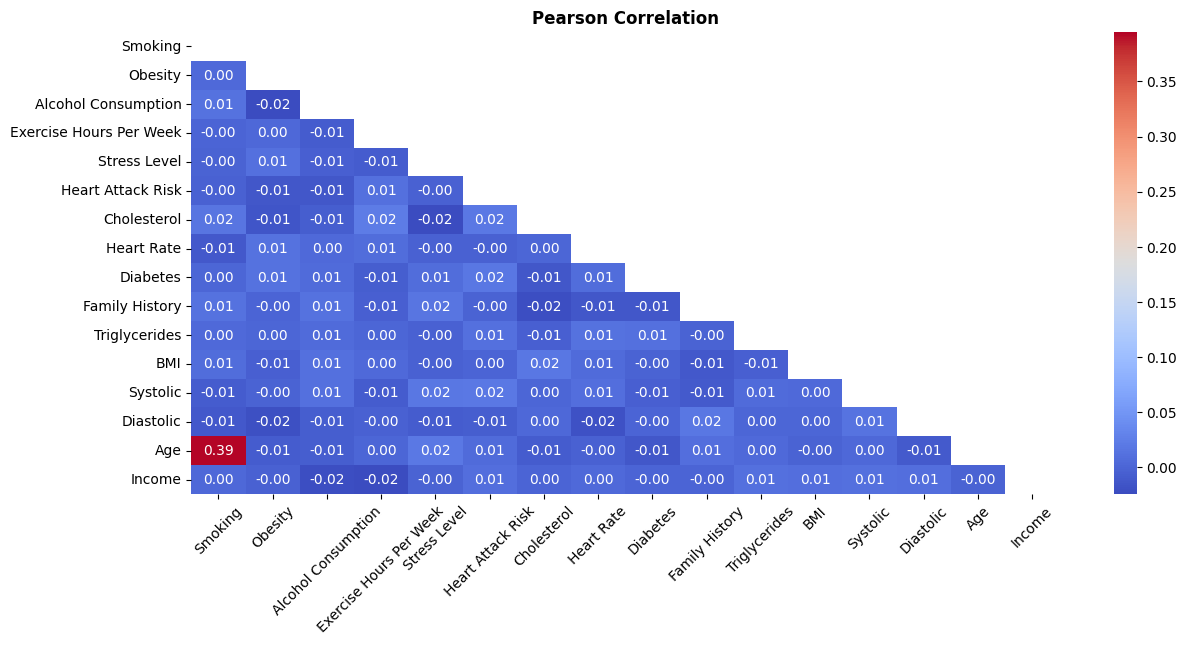

In [31]:
# Your code here
plt.figure(figsize=(14, 6))
corr_matrix_pear = merged_df.select_dtypes(include=["int64", 'uint8', 'float64']).corr(method='pearson')
mask_pear = np.triu(np.ones_like(corr_matrix_pear))
sns.heatmap(corr_matrix_pear, mask=mask_pear, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation", fontweight="bold")
plt.xticks(rotation=45);

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

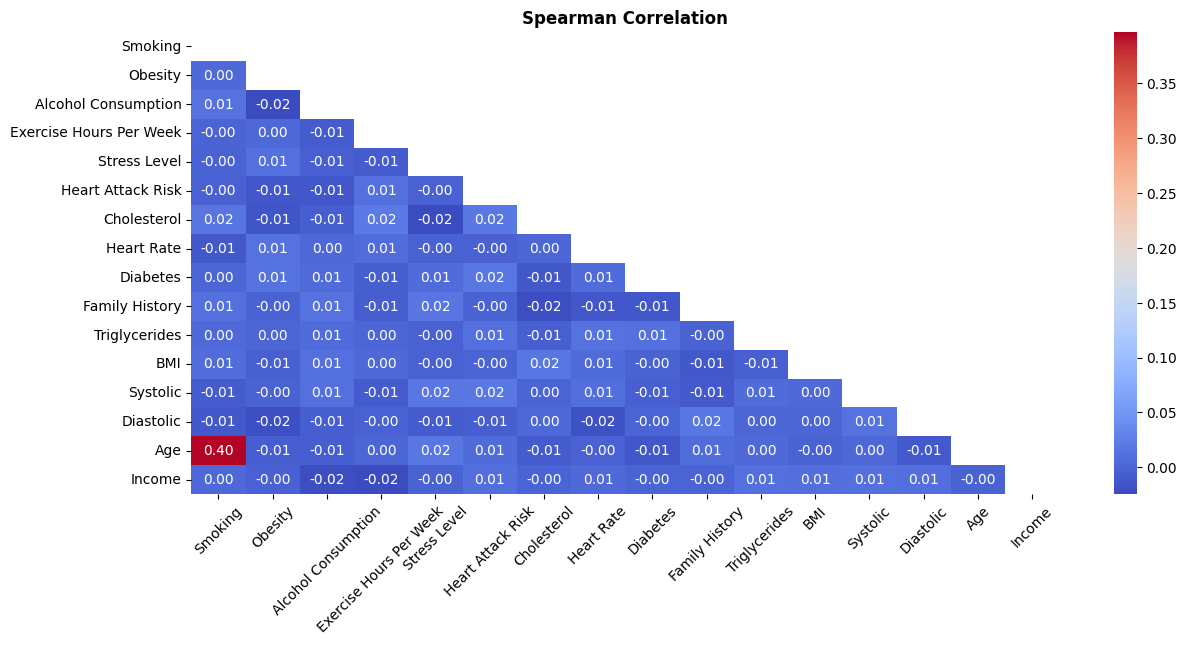

In [32]:
plt.figure(figsize=(14, 6))
corr_matrix_spear = merged_df.select_dtypes(include=["int64", 'uint8', 'float64']).corr(method='spearman')
mask_spear = np.triu(np.ones_like(corr_matrix_spear))
sns.heatmap(corr_matrix_spear, mask=mask_spear, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation", fontweight="bold")
plt.xticks(rotation=45);

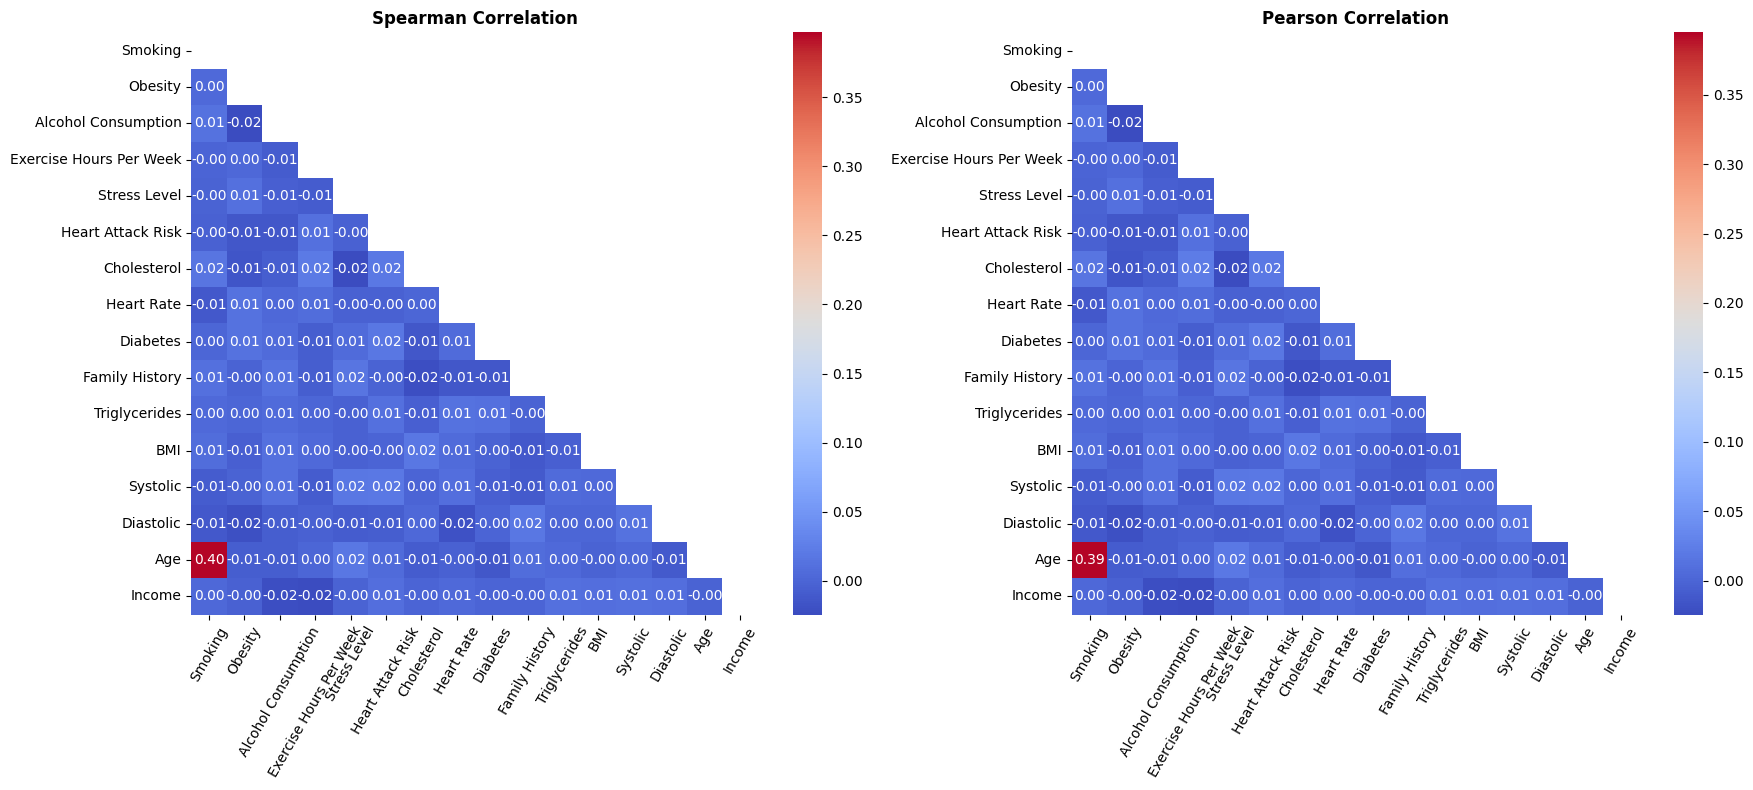

In [33]:
# Your code here

plt.figure(figsize=(18, 8))
plt.subplot(1,2,1)
sns.heatmap(corr_matrix_spear, mask=mask_spear, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation", fontweight="bold")
plt.xticks(rotation=60)

plt.subplot(1,2,2)
sns.heatmap(corr_matrix_pear, mask=mask_pear, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation", fontweight="bold")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [34]:
# Your code here
lifestyle["Heart Attack Risk"].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

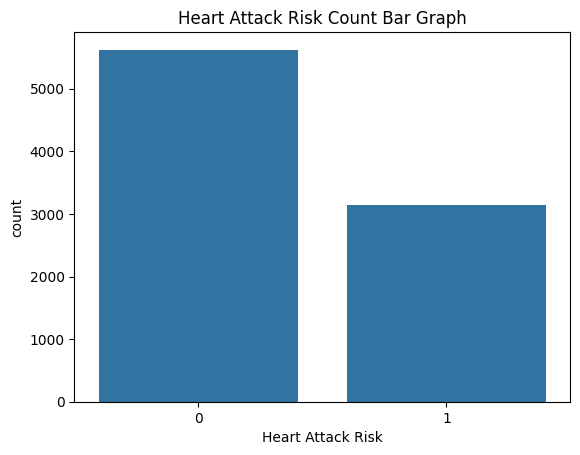

In [35]:
# Your code here
sns.countplot(data=lifestyle, x = "Heart Attack Risk", order=lifestyle["Heart Attack Risk"].value_counts().index)
plt.title("Heart Attack Risk Count Bar Graph");

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here:

##### Missing Values
* Unfortunately, there were no any missing values which simplified the wrangling pipeline significantly
* But if they were present, then appropriate strategies like dropna, fillna etc would have been used.
    - Dropna would have been used if data is abundant and dropping off the data can be afforded.
    - Fillna would have been used if data is less or if any filling stategies like mean, median etc can fill the NaN values without any biasness or distortion
  
##### Data Quality Issues
* Data seems to be fabricated but the values were not inconsistent.
* From the histograms and KDE plots, it is observed that the data are flat and not truly random as in normal distribution.
* There is class imbalance for `smoker` and `non smoker` data
* The systolic and diastolic BP were encoded in single `Blood Pressure` column making the numerical analysis difficult.
* The `Blood Pressure` column was splitted into `Systolic BP` and `Diastolic BP`. Other than that, for this excercise, I kept the data as it is.

##### Insights from EDA
* From the graphs, it can be seen that the data is not skewed.
* Heart attack risk is higher for male and is more likely in smokers.
* Indeed, the data is suprising. It can be seen that the diet has no effect in the heart attack risk which is quite contrary with that of the real world scenario which can mean that either the data is fabricated or the feature has genuinely low predictive power.
  
##### Correlation Findings
* Yes, they were similar and it does suggest that the relationships between the variables are largely linear and data is free from outliers.
* Age and Smoking show moderate collinearity with a Pearson correlation of 0.39 and Spearman of 0.40, suggesting a mild but consistent relationship. No other strong multicollinearity was detected.

##### Improvements
* I would try to get more data.
* There is class imbalance for `at risk` and `not at risk` data, so imbalance should be addressed.
* I would consider plotting the other numerical columns too so as to gain the insights on their relation with the heart attack risk